# Clustering Analysis

Run this notebook AFTER running the `microboone_open_data_non_empty.ipynb` notebook. Used to run thorough analysis on clustering: truth labels, anomaly scoring, alternative training morphology tests, etc. 

Used to validate and benchmark the training for our clustering methodology.

## Truth-Labeling 

Used to identify and generate truth labels for the clustering geometries in a CSV file. This is very crucial since subsequent studies will depend on these labelings. These should be generated and found in the `MBOONE_TruthLabels` folder. The truth-labeling here should be applied to both the raw and processed clusters so there should be a total of 3 truth-label CSV files, 2 for each cluster-size and 1 for the entire raw one.


The following labels should be:

### Variable | Measurement | Simple observable 
n_points | Counts of above-threshold pixels per cluster | Size

total_charge | Sum of ADC | Energy scale 

bbox_area | width x height | Overall spatial extent and range of interaction 

aspect_ratio | bbox width / height | Elongation 

linearity | PCA 1st-component variance fraction | Straightness 

n_pca_90 | Components for 90% variance | Dimensionality 

charge_conc | charge in brightest 10% of pixels | Lcalization or charge density dE/dx

hit_density | n_points/bbox_area | Compactness of interaction 

percent_nu | G4_id  | Percent of cluster that has a neutrino among all pixels that have charge

---

### What gets written

Built by `cluster_truth_labels.py`, driven by the cell below, into `MBOONE_TruthLabels/`:

| file | frame the observables are measured in | rows |
|---|---|---|
| `cluster_truth_raw_18x16.csv` | the variable-size crop, `clusters_raw_18x16.h5` | 355 041 |
| `cluster_truth_padded_50_18x16.csv` | the 144×112 frame, `clusters_padded_50_18x16.h5` | 355 041 |
| `cluster_truth_padded_75_18x16.csv` | the 288×176 frame, `clusters_padded_75_18x16.h5` | 355 041 |

Row `i` is row `i` of the raw **and** the padded HDF5 files, so the three tables join on `row`
with no bookkeeping. Keeping them separate is the point: `pad_to_target()` center-**crops**
anything bigger than the padding target, so in the padded frames a large cluster really does
have fewer pixels, less charge, a different bounding box and a different neutrino purity —
`was_cropped`, `frac_area_kept` and `frac_charge_kept` quantify exactly what each target threw
away.

Beyond the nine variables above each row carries ~50 more columns: identity and full-image
position, frame bookkeeping, extra shape/charge (`bbox_w`/`bbox_h`, `fill_frac`, `charge_mean`
/`max`/`std`, `n_saturated`, `pca_len1`/`pca_len2`, `pca_angle_deg`, charge centroid), the
hit-level semantic composition (`n_hits_cosmic`/`muon`/`pion`/`proton`/`other`,
`dominant_class`, `percent_nu_hits`) and the event's true neutrino (`nu_pdg`, `nu_energy_gev`,
`is_cc`, vertex position and distance). `MBOONE_TruthLabels/README.md` is the full column
dictionary.

Two notes on `percent_nu`. It is **charge-weighted** — neutrino-attributable hit charge over
total hit charge inside the frame — which is the same definition as the notebook's cached
`cluster_nu_chargefrac_18x16.npy` (reproduced to 5 × 10⁻⁷), with `percent_nu_hits` giving the
count-weighted twin. And it is a *hit*-level quantity while `total_charge` is a *wire*-level
one, so a cluster whose charge is all sub-hit-threshold has `n_hits = 0` and `percent_nu = NaN`.

`n_pca_90` is 1 or 2 by construction: these are 2-D images, so PCA has exactly two components
and the column is just `linearity >= 0.90`. `linearity` is its continuous form.


In [128]:

import os
import sys
from pathlib import Path

import numpy as np
import h5py
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import csv

DATASET = "crop"                             # Cluster identity [Typically crop now downscale]
PCTS = [50, 75]
TILE_TAG = "18x16"
SIZES = {50: (144, 112), 75: (288, 176)}      # padded frame per percentile
TOTAL_IMAGES, SEED = 60000, 42                # MUST match Clustering_Training.py's split
CHUNK, PB = 512, {50: 256, 75: 64}            # HDF5 rows per read / predict batch (fallback path only)



In [129]:
# Build (or load) the three truth-label tables and show what is in them.
#
# The generator lives in cluster_truth_labels.py because it is a batch job over ~14 Gpx of
# cluster pixels plus ~50 GB of raw bnb_WithWire_NN.h5 truth -- a few minutes, not a cell you
# want to re-run by accident.  This cell just drives it: if the CSVs already exist it loads
# them, otherwise it builds them once and caches them in MBOONE_TruthLabels/.
import importlib
import subprocess

import pandas as pd

try:
    import cluster_truth_labels as CTL
except ImportError:
    for _p in (".", "main_project/MBOONE"):
        if _p not in sys.path:
            sys.path.insert(0, _p)
    import cluster_truth_labels as CTL
# Python caches modules, so a plain `import` in a long-lived kernel keeps whatever version was
# first loaded.  Reload so edits to cluster_truth_labels.py take effect without a restart.
importlib.reload(CTL)

CIMG_T, RAW_DIR_T, TRUTH_DIR = CTL.resolve_paths()
TRUTH_FILES = {"raw": "cluster_truth_raw_%s.csv" % TILE_TAG}
TRUTH_FILES.update({p: "cluster_truth_padded_%d_%s.csv" % (p, TILE_TAG) for p in PCTS})

missing = [n for n in TRUTH_FILES.values() if not (TRUTH_DIR / n).exists()]
if missing:
    print("building %d missing truth table(s): %s\nthis takes a few minutes -- output below\n"
          % (len(missing), ", ".join(missing)))
    subprocess.run([sys.executable, str(Path(CTL.__file__).resolve())], check=True)

TRUTH = {k: pd.read_csv(TRUTH_DIR / v) for k, v in TRUTH_FILES.items()}

print("truth tables in %s" % TRUTH_DIR)
for k, v in TRUTH_FILES.items():
    d = TRUTH[k]
    frame = "variable" if k == "raw" else "%dx%d" % (d["frame_w"].iloc[0], d["frame_h"].iloc[0])
    print("  %-34s %6d rows x %2d cols   frame %-9s %5.1f%% cropped"
          % (v, len(d), d.shape[1], frame, 100.0 * d["was_cropped"].mean()))


REQUESTED = ["n_points", "total_charge", "bbox_area", "aspect_ratio", "linearity",
             "n_pca_90", "charge_conc", "hit_density", "percent_nu"]
print("\nmedian of each requested observable, by frame  (raw = nothing cropped away)")
print(pd.DataFrame({("raw" if k == "raw" else "%dth pct" % k): TRUTH[k][REQUESTED].median()
                    for k in TRUTH_FILES}).to_string(float_format=lambda v: "%.4g" % v))

# Truth composition of the RAW frame: the boolean label used elsewhere in this notebook is a
# tile-overlap flag, so most "neutrino" clusters are actually cosmic-dominated -- percent_nu
# is the continuous version that says so.
_r = TRUTH["raw"]
_h = _r["n_hits"] > 0
print("\nraw frame: %d clusters | %d with reconstructed hits | dominant truth class:"
      % (len(_r), int(_h.sum())))
print(_r["dominant_class"].value_counts(dropna=False).to_string())
print("\npercent_nu (charge-weighted neutrino purity, over the rows that have hits):")
print("  == 0        %6.2f%%   pure cosmic" % (100.0 * float((_r.loc[_h, "percent_nu"] == 0).mean())))
print("  > 2%%        %6.2f%%   any neutrino charge at all"
      % (100.0 * float((_r.loc[_h, "percent_nu"] > 2).mean())))
print("  > 50%%       %6.2f%%   neutrino-dominated"
      % (100.0 * float((_r.loc[_h, "percent_nu"] > 50).mean())))
print("  is_nu_tile  %6.2f%%   the coarse boolean, for comparison"
      % (100.0 * float((_r["is_nu_tile"] == 1).mean())))

TRUTH["raw"].head()


truth tables in MBOONE_TruthLabels
  cluster_truth_raw_18x16.csv        355041 rows x 61 cols   frame variable    0.0% cropped
  cluster_truth_padded_50_18x16.csv  355041 rows x 61 cols   frame 144x112    61.1% cropped
  cluster_truth_padded_75_18x16.csv  355041 rows x 61 cols   frame 288x176    34.8% cropped

median of each requested observable, by frame  (raw = nothing cropped away)
                   raw  50th pct  75th pct
n_points           378       274       375
total_charge 2.267e+04 1.563e+04 2.174e+04
bbox_area         7700      4558      7175
aspect_ratio      1.55     1.455     1.566
linearity       0.9896     0.993     0.991
n_pca_90             1         1         1
charge_conc     0.1721    0.1723     0.172
hit_density    0.03952   0.05312   0.04218
percent_nu           0         0         0

raw frame: 355041 clusters | 355006 with reconstructed hits | dominant truth class:
dominant_class
cosmic    338230
other       7046
muon        6577
proton      2603
pion         5

,row,cluster_id,source_file_id,source_event_index,n_tiles,bbox_wire_lo,bbox_wire_hi,bbox_time_lo,bbox_time_hi,tile_row_lo,...,is_nu_tile,nu_pdg,nu_energy_gev,is_cc,nu_vtx_wire,nu_vtx_time,vtx_in_frame,vtx_dwire,vtx_dtime,vtx_dist
0,0,1,0,0,27,0,288,32,240,0,...,0,14,1.54585,0,3211,350,0,-3082.21,-209.7190,3089.34
1,1,2,0,0,75,0,990,240,368,0,...,0,14,1.54585,0,3211,350,0,-2809.58,-40.2959,2809.87
2,2,7,0,0,7,594,738,368,432,34,...,0,14,1.54585,0,3211,350,0,-2546.40,51.8068,2546.93
3,3,14,0,0,9,882,990,432,544,50,...,0,14,1.54585,0,3211,350,0,-2290.17,133.6050,2294.07
4,4,17,0,0,5,1098,1170,224,304,62,...,0,14,1.54585,0,3211,350,0,-2076.01,-87.5362,2077.85


### Cluster v.s. original v.s. hits

cluster row 348653  (pool='neutrino')  -- set PICK_ROW=348653 to pin it, or call show_cluster(n)


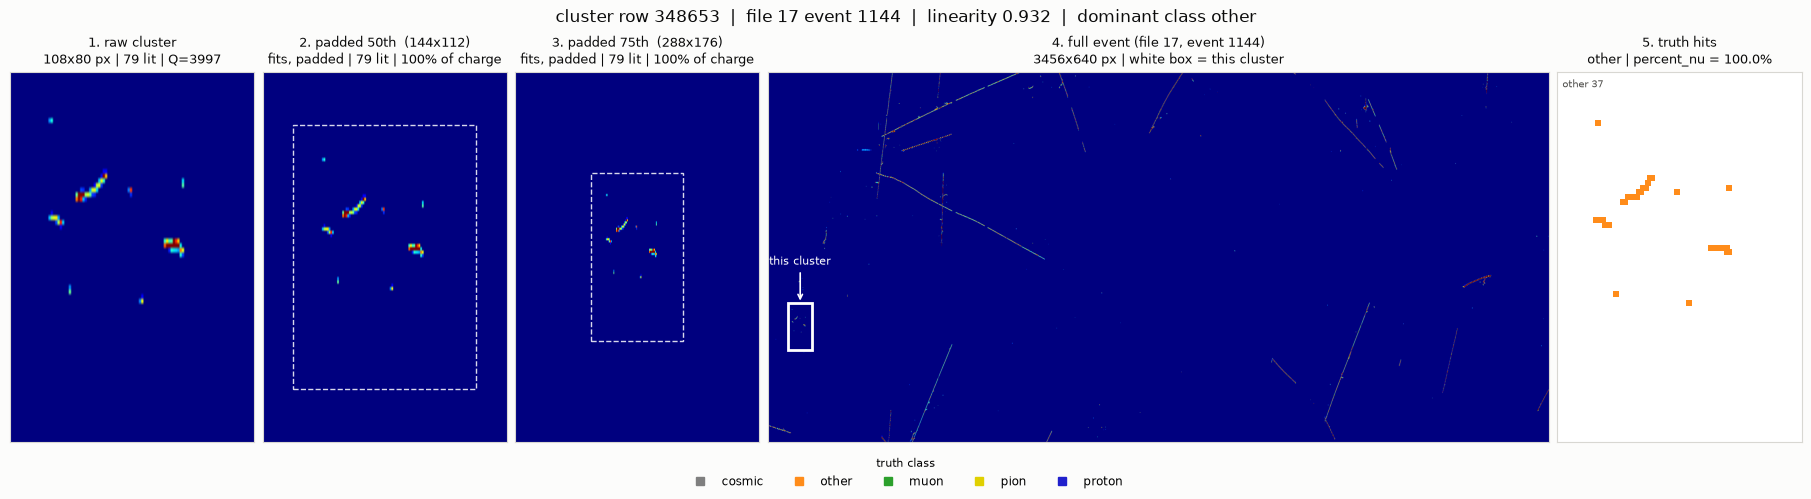

348653

In [130]:
#
#   1 raw cluster   the variable-size crop tile_cluster.py pass 1 wrote
#   2 padded 50th   the 144x112 frame the autoencoder is actually fed
#   3 padded 75th   the 288x176 frame
#   4 full event    the whole 3456x640 plane-2 image the cluster was cut out of
#   5 truth hits    every plane-2 hit in the cluster's box, on white, coloured by the Geant4
#                   particle that deposited most of its energy

from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

# Which cluster to show.  A uniformly random pick is ~90% pure cosmic, which makes panel 5 an
# uninformative wall of grey, so the default draws from the neutrino-rich pool instead.
PICK_POOL = "neutrino"    # "any" | "neutrino" (percent_nu > 50) | "cropped" (neutrino AND cropped)
PICK_ROW = None           # set to an int to pin one cluster; None = random
PICK_SEED = None          # set to an int to make the random pick reproducible

CLASS_COL = {"cosmic": "#7f7f7f", "other": "#ff8c1a", "muon": "#2ca02c",
             "pion": "#e0d000", "proton": "#2020cc"}
CLASS_ORDER = ["cosmic", "other", "muon", "pion", "proton"]
INK, INK2, GRIDC = "#0b0b0b", "#52514e", "#d8d7d2"


def pick_cluster(pool=PICK_POOL, row=PICK_ROW, seed=PICK_SEED):
    if row is not None:
        return int(row)
    r = TRUTH["raw"]
    cand = {"any": np.arange(len(r)),
            "neutrino": np.nonzero((r.percent_nu > 50).to_numpy())[0],
            "cropped": np.nonzero(((TRUTH[PCTS[0]].was_cropped == 1)
                                   & (r.percent_nu > 50)).to_numpy())[0]}[pool]
    if cand.size == 0:
        raise ValueError("pool %r is empty" % pool)
    return int(np.random.default_rng(seed).choice(cand))


def show_cluster(row):
    """The five-panel display for one cluster (same row index in all three truth CSVs)."""
    m = TRUTH["raw"].loc[row]
    py1, py2 = int(m.bbox_wire_lo), int(m.bbox_wire_hi)      # wire = image axis 0
    px1, px2 = int(m.bbox_time_lo), int(m.bbox_time_hi)      # time = image axis 1
    fid, ev = int(m.source_file_id), int(m.source_event_index)

    with h5py.File(str(CIMG_T / ("clusters_raw_%s.h5" % TILE_TAG)), "r") as f:
        lo, hi = int(f["image_offsets"][row]), int(f["image_offsets"][row + 1])
        raw_img = f["image_data"][lo:hi].reshape(int(f["image_width_px"][row]),
                                                 int(f["image_height_px"][row]))
        srcs = [s.decode() if isinstance(s, bytes) else s for s in f.attrs["source_files"]]
        CUT, SAT = float(f.attrs["cutoff"]), float(f.attrs["saturation"])

    pad_img = {}
    for p in PCTS:
        with h5py.File(str(CIMG_T / ("clusters_padded_%d_%s.h5" % (p, TILE_TAG))), "r") as f:
            pad_img[p] = f["images"][row]

    # The full event, cut exactly the way tile_cluster.apply_cuts() cut it before extracting.
    proc = RAW_DIR_T / "processed_npy" / srcs[fid]
    full = None
    if proc.exists():
        with h5py.File(str(proc), "r") as f:
            full = f["image"][ev].astype(np.float32)
        full[full < CUT] = 0.0
        np.clip(full, None, SAT, out=full)

    raw_h5 = RAW_DIR_T / srcs[fid].replace("_plane2_images", "")
    hw = ht = hc = None
    if raw_h5.exists():
        hw, ht, _hq, hc = CTL.event_hit_truth(raw_h5, ev)

    fig = plt.figure(figsize=(18.0, 4.9), constrained_layout=True)
    fig.patch.set_facecolor("#fcfcfb")
    gs = fig.add_gridspec(1, 5, width_ratios=[1, 1, 1, 3.2, 1])
    ax = [fig.add_subplot(gs[0, i]) for i in range(5)]

    def chrome(a, title, sub=""):
        a.set_title(title + ("\n" + sub if sub else ""), fontsize=9.5, color=INK)
        a.set_xticks([]); a.set_yticks([])
        for sp in a.spines.values():
            sp.set_color(GRIDC)

    # 1 -- raw crop, in FULL-image coordinates so panel 5 lines up with it
    ax[0].imshow(raw_img.T, origin="lower", cmap="jet", vmin=0, vmax=SAT, aspect="auto",
                 extent=(py1, py2, px1, px2))
    chrome(ax[0], "1. raw cluster", "%dx%d px | %d lit | Q=%.0f"
           % (m.crop_w, m.crop_h, m.n_points, m.total_charge))

    # 2, 3 -- the padded frames, with the real-data region outlined
    for k, p in enumerate(PCTS):
        a = ax[1 + k]
        tw, tt = SIZES[p]
        a.imshow(pad_img[p].T, origin="lower", cmap="jet", vmin=0, vmax=SAT, aspect="auto",
                 extent=(0, tw, 0, tt))
        s0, h2, s1, w2 = CTL.crop_window(py2 - py1, px2 - px1, tw, tt)
        a.add_patch(Rectangle(((tw - h2) // 2, (tt - w2) // 2), h2, w2, fill=False,
                              ec="white", lw=1.0, ls="--", alpha=0.85))
        q = TRUTH[p].loc[row]
        chrome(a, "%d. padded %dth  (%dx%d)" % (2 + k, p, tw, tt),
               "%s | %d lit | %.0f%% of charge"
               % ("CROPPED" if q.was_cropped else "fits, padded", q.n_points,
                  100.0 * q.frac_charge_kept))

    # 4 -- the whole event, with this cluster boxed
    a = ax[3]
    if full is None:
        a.text(0.5, 0.5, "processed event image not found:\n%s" % proc, ha="center",
               va="center", fontsize=8, color=INK2, transform=a.transAxes)
    else:
        a.imshow(full.T, origin="lower", cmap="jet", vmin=0, vmax=SAT, aspect="auto",
                 extent=(0, full.shape[0], 0, full.shape[1]))
        a.add_patch(Rectangle((py1, px1), py2 - py1, px2 - px1, fill=False, ec="white", lw=2.0))
        # label below the box when the cluster sits high in the event, else above -- otherwise
        # it lands outside the axes and gets clipped
        high = px2 > 0.75 * full.shape[1]
        a.annotate("this cluster", xy=(0.5 * (py1 + py2), px1 if high else px2),
                   xytext=(0, -26 if high else 26), textcoords="offset points",
                   ha="center", va="top" if high else "bottom", fontsize=8, color="white",
                   arrowprops=dict(arrowstyle="->", color="white", lw=1.2))
    chrome(a, "4. full event (file %02d, event %d)" % (fid, ev),
           "3456x640 px | white box = this cluster")

    # 5 -- truth hits inside the cluster's box, white background, one colour per class
    a = ax[4]
    a.set_facecolor("white")
    if hw is None:
        a.text(0.5, 0.5, "no plane-2 truth hits for this event\n(or raw file missing:\n%s)"
               % raw_h5.name, ha="center", va="center", fontsize=8, color=INK2,
               transform=a.transAxes)
    else:
        inb = (hw >= py1) & (hw < py2) & (ht >= px1) & (ht < px2)
        dot = float(np.clip(2600.0 / max(py2 - py1, px2 - px1), 2.0, 26.0))
        tally = []
        for name in CLASS_ORDER:
            sel = inb & (hc == name)
            if sel.any():
                tally.append("%s %d" % (name, int(sel.sum())))
                a.scatter(hw[sel], ht[sel], s=dot, marker="s", linewidths=0,
                          color=CLASS_COL[name])
        a.text(0.02, 0.98, "\n".join(tally) or "no hits in this box", transform=a.transAxes,
               ha="left", va="top", fontsize=7.5, color=INK2)
        a.set_xlim(py1, py2)
        a.set_ylim(px1, px2)
    chrome(a, "5. truth hits", "%s | percent_nu = %.1f%%" % (m.dominant_class, m.percent_nu))

    fig.legend(handles=[Line2D([], [], marker="s", ls="", ms=6, color=CLASS_COL[n], label=n)
                        for n in CLASS_ORDER],
               loc="outside lower center", ncol=5, frameon=False, fontsize=8.5,
               title="truth class", title_fontsize=8)
    fig.suptitle("cluster row %d  |  file %02d event %d  |  linearity %.3f  |  dominant class %s"
                 % (row, fid, ev, m.linearity, m.dominant_class), fontsize=12, color=INK)
    plt.show()
    return row


ROW = pick_cluster()
print("cluster row %d  (pool=%r)  -- set PICK_ROW=%d to pin it, or call show_cluster(n)"
      % (ROW, PICK_POOL, ROW))
show_cluster(ROW)


## Anomaly Score measurements


In [131]:

COSMIC_C, NU_C = "#4C72B0", "#C44E52"
INK, INK2, GRIDC = "#0b0b0b", "#52514e", "#d8d7d2"


def _find(cands):
    return next((p for p in cands if p.exists()), None)


CIMG = _find([Path("clusterImages"), Path("main_project/MBOONE/clusterImages")])
SAVE = _find([Path("savedModel"), Path("main_project/MBOONE/savedModel")])


def padded_path(pct):
    return CIMG / ("clusters_padded_%d_%s.h5" % (pct, TILE_TAG))


def model_path(pct):
    return (SAVE / ("cluster_%d_%s" % (pct, TILE_TAG))
            / ("unsupervised_cluster_%d_%s.h5" % (pct, TILE_TAG)))


def score_cache(pct):
    return CIMG / ("eval_scores_%d_%s.npz" % (pct, TILE_TAG))


def test_rows(n_total, total=TOTAL_IMAGES, seed=SEED):
    """The exact held-out test rows Clustering_Training.py never trains on (sorted -> h5py-indexable)."""
    idx = np.arange(n_total)
    np.random.default_rng(seed).shuffle(idx)
    idx = idx[:min(total, n_total)]
    n_tr, n_va = int(round(0.5 * len(idx))), int(round(0.1 * len(idx)))
    return np.sort(idx[n_tr + n_va:])                       # test = last 40%


def _score_from_model(pct):
    """Cache-miss path: rebuild the (identical) architecture and read weights by hand -- keras's
    HDF5 loader crashes on this env's h5py>=3 -- then score the held-out test clusters."""
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")     # CPU only
    from tensorflow import keras
    try:
        from Clustering_Training import build_unsupervised
    except ImportError:
        for _p in (".", "main_project/MBOONE"):
            if _p not in sys.path:
                sys.path.insert(0, _p)
        from Clustering_Training import build_unsupervised

    model = build_unsupervised((*SIZES[pct], 1))
    with h5py.File(str(model_path(pct)), "r") as f:
        g = f["model_weights"]
        flat = []
        for layer in model.layers:
            if not layer.weights:
                continue
            lg = g[layer.name]
            names = [n.decode() if isinstance(n, (bytes, bytearray)) else n
                     for n in lg.attrs["weight_names"]]
            flat += [np.asarray(lg[n]) for n in names]
    model.set_weights(flat)

    is_nu_full = np.load(CIMG / ("cluster_truth_labels_%s.npy" % TILE_TAG))   # indexed by RAW order
    with h5py.File(str(padded_path(pct)), "r") as f:
        imgs = f["images"]
        te = test_rows(imgs.shape[0])
        raw, inten = [], []
        for s in range(0, len(te), CHUNK):
            X = imgs[te[s:s + CHUNK]][..., None].astype("float32")
            rec = model.predict(X, batch_size=PB[pct], verbose=0)
            raw.append(np.mean((X - rec) ** 2, axis=(1, 2, 3)))
            inten.append(X.sum(axis=(1, 2, 3)))
    keras.backend.clear_session()
    out = dict(raw=np.concatenate(raw), inten=np.concatenate(inten),
               is_nu=is_nu_full[te], idx=te, raw_rows=te)    # crop rows == raw-cluster order
    np.savez(score_cache(pct), **out)
    print("cached %s" % score_cache(pct).name)
    return out


NQ_CHARGE = 40          # charge quantile bins for the running median used by charge_normalize


def charge_normalize(raw, inten, nq=NQ_CHARGE, min_in_bin=20):
    """Anomaly score as a MULTIPLE of what clusters of the SAME charge typically score.

    `scaled` (= raw / charge) assumes the MSE is exactly proportional to charge.  It is not: the
    fitted log-log slope is 0.95 (50th) / 1.09 (75th) and the relation is curved, which is why
    `scaled` still carries rho = 0.11 / 0.36 with charge -- and it lands on an unreadable ~1e-3
    scale.  Instead, bin the clusters by charge, take the MEDIAN raw score in each bin, and divide
    each cluster by the interpolated median at its OWN charge.

    The result is centred on 1.0 and reads directly:
        1.0 = a perfectly ordinary reconstruction for a cluster that bright
        3.0 = three times the error typical at that brightness  -> genuinely anomalous
        0.5 = reconstructed twice as well as its peers
    Its rank correlation with charge is ~0.01, i.e. charge really is a non-factor -- so a faint
    cluster and a bright one are judged on the same footing.
    """
    out = np.full(raw.shape, np.nan)
    g = (raw > 0) & (inten > 0)
    li, lr = np.log10(inten[g]), np.log10(raw[g])
    edges = np.unique(np.quantile(li, np.linspace(0.0, 1.0, nq + 1)))
    which = np.clip(np.searchsorted(edges, li, side="right") - 1, 0, len(edges) - 2)
    cx, cy = [], []
    for b in range(len(edges) - 1):
        m = which == b
        if int(m.sum()) >= min_in_bin:              # sparse tail bins would give a noisy median
            cx.append(np.median(li[m]))
            cy.append(np.median(lr[m]))
    out[g] = raw[g] / 10.0 ** np.interp(li, np.array(cx), np.array(cy))   # flat past the ends
    return out


def cluster_scores(pct):
    """dict(raw, scaled, norm, inten, is_nu, idx) over the held-out test clusters of one percentile."""
    c = score_cache(pct)
    d = dict(np.load(c)) if c.exists() else _score_from_model(pct)
    raw = d["raw"].astype(np.float64)
    inten = d["inten"].astype(np.float64)
    scaled = np.full(raw.shape, np.nan)
    nz = inten > 0
    scaled[nz] = raw[nz] / inten[nz]        # no charge -> nothing to divide by; NaN drops out of the plots
    return dict(raw=raw, scaled=scaled, norm=charge_normalize(raw, inten), inten=inten,
                is_nu=d["is_nu"].astype(bool), idx=d["idx"], n_nocharge=int((~nz).sum()))


def _rank(a):
    """Average ranks (ties shared) so Spearman is well defined on the many equal-valued scores."""
    a = np.asarray(a, float)
    order = np.argsort(a, kind="mergesort")
    r = np.empty(a.size, float)
    r[order] = np.arange(a.size, dtype=float)
    s = a[order]
    i = 0
    while i < s.size:
        j = i
        while j + 1 < s.size and s[j + 1] == s[i]:
            j += 1
        if j > i:
            r[order[i:j + 1]] = 0.5 * (i + j)
        i = j + 1
    return r


def spearman(a, b):
    ra, rb = _rank(a), _rank(b)
    ra, rb = ra - ra.mean(), rb - rb.mean()
    den = np.sqrt(float((ra * ra).sum()) * float((rb * rb).sum()))
    return float((ra * rb).sum() / den) if den > 0 else float("nan")


def _style_ax(ax):
    """Common chrome: light grid, no top/right spines, muted ticks."""
    ax.set_facecolor("#fcfcfb")
    ax.grid(True, which="major", color=GRIDC, linewidth=0.6)
    ax.set_axisbelow(True)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    for sp in ("left", "bottom"):
        ax.spines[sp].set_color(GRIDC)
    ax.tick_params(colors=INK2, labelsize=9)


SCORES = {p: cluster_scores(p) for p in PCTS}     # <-- shared by every plot cell below

print("DATASET = %r  |  models: %s" % (DATASET, ", ".join(model_path(p).parent.name for p in PCTS)))
for p in PCTS:
    z = SCORES[p]
    print("%dth pct: %d test clusters (%d neutrino)  raw %.3g-%.3g  charge %.3g-%.3g"
          % (p, z["raw"].size, int(z["is_nu"].sum()), z["raw"].min(), z["raw"].max(),
             z["inten"].min(), z["inten"].max())
          + ("  [%d with zero charge -> excluded from scaled/log plots]" % z["n_nocharge"]
             if z["n_nocharge"] else ""))

DATASET = 'crop'  |  models: cluster_50_18x16, cluster_75_18x16
50th pct: 24000 test clusters (2141 neutrino)  raw 0-637  charge 0-1.93e+05  [59 with zero charge -> excluded from scaled/log plots]
75th pct: 24000 test clusters (2141 neutrino)  raw 0-363  charge 0-2.89e+05  [1 with zero charge -> excluded from scaled/log plots]


In [132]:
# ---- Shared machinery for the "input | reconstruction | |residual| | truth" figures ----
# Two example figures below use this: one picks clusters on the SCALED score (raw / charge), one on
# the CHARGE-NORMALIZED score.  Everything they share lives here so neither cell duplicates it.
#
# The TRUTH panel follows the pynuml semantic_label plot: every plane-2 HIT inside the cluster's
# frame, on white, coloured by the Geant4 particle that deposited most of its energy.  A hit with
# no Geant4 parent at all comes from the beam-off cosmic overlay -> class "cosmic".
# Truth needs the RAW bnb_WithWire_<NN>.h5 files; if they are missing the panel says so instead of
# failing the cell.  TensorFlow is imported lazily, only when a model is actually loaded.
from matplotlib.lines import Line2D
from matplotlib.ticker import NullFormatter      # also used by the histogram cells below

TIME_FACTOR = 10          # full image is time-downsampled by 10 (6400 ticks -> 640 px)
RAW_DIR = _find([Path("../../data/ubopendata"), Path("data/ubopendata"),
                 Path("../../../data/ubopendata")])

# pynuml-style semantic classes, same palette as the semantic_label plot.
PDG_CLASS = {13: "muon", 211: "pion", 2212: "proton"}          # |pdg| -> class; rest = "other"
CLASS_COL = {"cosmic": "#7f7f7f", "other": "#ff8c1a", "muon": "#2ca02c",
             "pion": "#e0d000", "proton": "#2020cc"}
CLASS_ORDER = ["cosmic", "other", "muon", "pion", "proton"]

_MODEL_CACHE = {}


def load_model(pct):
    """The trained cluster AE for one percentile (cached; weights read by hand, see setup cell)."""
    if pct in _MODEL_CACHE:
        return _MODEL_CACHE[pct]
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    try:
        from Clustering_Training import build_unsupervised
    except ImportError:
        for _p in (".", "main_project/MBOONE"):
            if _p not in sys.path:
                sys.path.insert(0, _p)
        from Clustering_Training import build_unsupervised

    m = build_unsupervised((*SIZES[pct], 1))
    with h5py.File(str(model_path(pct)), "r") as f:
        g = f["model_weights"]
        flat = []
        for layer in m.layers:
            if not layer.weights:
                continue
            lg = g[layer.name]
            names = [n.decode() if isinstance(n, (bytes, bytearray)) else n
                     for n in lg.attrs["weight_names"]]
            flat += [np.asarray(lg[n]) for n in names]
    m.set_weights(flat)
    _MODEL_CACHE[pct] = m
    return m


def _frame_offsets(h, w, tw, tt):
    """Mirror tile_cluster.pad_to_target: (crop start, pad start) for each axis.

    pad_to_target center-CROPS an oversized cluster then center-PADS to the target, so a full-image
    pixel maps into the padded frame as  (px - bbox_start) - crop_start + pad_start.
    """
    s0, s1 = max(0, (h - tw) // 2), max(0, (w - tt) // 2)      # center-crop start
    h2, w2 = min(h, tw), min(w, tt)                            # size after cropping
    return s0, s1, (tw - h2) // 2, (tt - w2) // 2              # + center-pad start


def cluster_truth_hits(pct, row):
    """Plane-2 hits inside cluster `row`'s padded frame, as (wire_px, time_px, class name).

    Truth chain: edep_table gives, per hit, the Geant4 tracks that deposited in it; the track with
    the largest summed energy_fraction wins, and particle_table turns its g4_id into a PDG code.
    A hit with no edep entry has no Geant4 parent -> it is cosmic-overlay data, class "cosmic".
    """
    with h5py.File(str(padded_path(pct)), "r") as pf:
        srcs = [s.decode() if isinstance(s, bytes) else s for s in pf.attrs["source_files"]]
        fid = int(pf["metadata/source_file_id"][row])
        ev = int(pf["metadata/source_event_index"][row])
        py1, py2, px1, px2 = [int(v) for v in pf["metadata/bbox_pixel_coords"][row]]
    if RAW_DIR is None:
        return None, "data/ubopendata not found"
    raw_path = RAW_DIR / srcs[fid].replace("_plane2_images", "")
    if not raw_path.exists():
        return None, str(raw_path)

    with h5py.File(str(raw_path), "r") as f:
        hs = f["hit_table/event_id.seq_cnt"][:]
        h_off = np.concatenate([[0], np.cumsum(hs[:, 1])])
        a, b = int(h_off[ev]), int(h_off[ev + 1])
        plane = f["hit_table/local_plane"][a:b, 0]
        wire = f["hit_table/local_wire"][a:b, 0].astype(np.int64)
        tick = f["hit_table/local_time"][a:b, 0]

        # local hit index -> dominant g4_id (largest summed edep energy fraction)
        dom = np.full(b - a, -1, dtype=np.int64)
        es = f["edep_table/event_id.seq_cnt"][:]
        e_off = np.concatenate([[0], np.cumsum(es[:, 1])])
        erow = {int(e): i for i, e in enumerate(es[:, 0])}
        if ev in erow:
            j = erow[ev]
            s, t = int(e_off[j]), int(e_off[j + 1])
            eh = f["edep_table/hit_id"][s:t, 0].astype(np.int64)
            eg = f["edep_table/g4_id"][s:t, 0].astype(np.int64)
            ef = f["edep_table/energy_fraction"][s:t, 0].astype(np.float64)
            ok = (eh >= 0) & (eh < b - a)
            eh, eg, ef = eh[ok], eg[ok], ef[ok]
            order = np.lexsort((-ef, eh))            # per hit, biggest fraction first
            first = np.ones(eh.size, bool)
            first[1:] = eh[order][1:] != eh[order][:-1]
            dom[eh[order][first]] = eg[order][first]

        # g4_id -> PDG
        pdg_of = {}
        ps = f["particle_table/event_id.seq_cnt"][:]
        p_off = np.concatenate([[0], np.cumsum(ps[:, 1])])
        prow = {int(e): i for i, e in enumerate(ps[:, 0])}
        if ev in prow:
            k = prow[ev]
            s, t = int(p_off[k]), int(p_off[k + 1])
            pdg_of = dict(zip(f["particle_table/g4_id"][s:t, 0].astype(np.int64).tolist(),
                              f["particle_table/g4_pdg"][s:t, 0].astype(np.int64).tolist()))

    # collection plane, inside this cluster's bounding box in FULL-image pixel coords
    tpx = np.floor(tick / TIME_FACTOR).astype(np.int64)
    m = ((plane == 2) & (wire >= py1) & (wire < py2) & (tpx >= px1) & (tpx < px2))
    if not m.any():
        return (np.empty(0), np.empty(0), np.array([], dtype=object)), None

    tw, tt = SIZES[pct]
    s0, s1, t0, t1 = _frame_offsets(py2 - py1, px2 - px1, tw, tt)
    fw = (wire[m] - py1) - s0 + t0
    ft = (tpx[m] - px1) - s1 + t1
    inside = (fw >= 0) & (fw < tw) & (ft >= 0) & (ft < tt)     # oversized clusters lose the edges

    cls = []
    for g in dom[m][inside]:
        if g < 0:
            cls.append("cosmic")                               # no Geant4 parent -> cosmic overlay
        else:
            cls.append(PDG_CLASS.get(abs(int(pdg_of.get(int(g), 0))), "other"))
    return (fw[inside], ft[inside], np.array(cls, dtype=object)), None


def usable_pos(pct, key):
    """Row positions (into the SCORES arrays) where `key` and the raw score are both defined."""
    z = SCORES[pct]
    return np.where(np.isfinite(z[key]) & (z[key] > 0) & (z["raw"] > 0))[0]


def pick_quantile(pct, key, q, pos=None):
    """Position of the cluster whose `key` value sits closest to quantile q."""
    z = SCORES[pct]
    pos = usable_pos(pct, key) if pos is None else pos
    target = np.quantile(z[key][pos], q)
    return int(pos[np.argmin(np.abs(z[key][pos] - target))])


def render_examples(pct, picks, key, key_label, suptitle):
    """input | reconstruction | |residual| | truth, one row per pick.

    picks = [(position into the SCORES arrays, row label), ...]; `key` names the score the picks
    were made on, so each row label can quote it alongside the raw MSE and the charge percentile.
    """
    z = SCORES[pct]
    idx, raw, inten = z["idx"], z["raw"], z["inten"]
    pos = usable_pos(pct, key)
    tw, tt = SIZES[pct]

    rows = sorted({int(idx[p]) for p, _ in picks})
    with h5py.File(str(padded_path(pct)), "r") as f:
        imgs = {r: f["images"][r] for r in rows}
    model = load_model(pct)

    fig, axes = plt.subplots(len(picks), 4, figsize=(12.8, 2.9 * len(picks)), squeeze=False)
    fig.patch.set_facecolor("#fcfcfb")
    seen = set()
    for r, (p, tag) in enumerate(picks):
        inp = imgs[int(idx[p])].astype("float32")
        rec = model.predict(inp[None, ..., None], batch_size=1, verbose=0)[0, :, :, 0]
        vmax = max(1.0, float(inp.max()))
        for c, (im, ttl) in enumerate(((inp, "input"), (rec, "reconstruction"),
                                       (np.abs(inp - rec), "|residual|"))):
            axes[r, c].imshow(im.T, origin="lower", cmap="jet", vmin=0, vmax=vmax, aspect="auto")
            axes[r, c].set_xticks([])
            axes[r, c].set_yticks([])
            if r == 0:
                axes[r, c].set_title(ttl, color=INK, fontsize=10)

        # ---- 4th column: truth ----
        a = axes[r, 3]
        a.set_facecolor("white")
        res, err = cluster_truth_hits(pct, int(idx[p]))
        if res is None:
            a.text(0.5, 0.5, "raw file not found:\n%s" % err, ha="center", va="center",
                   fontsize=7, color="#b03030", transform=a.transAxes)
        else:
            fw, ft, cls = res
            counts = []
            for name in CLASS_ORDER:
                sel = cls == name
                if not sel.any():
                    continue
                seen.add(name)
                counts.append("%s %d" % (name, int(sel.sum())))
                a.scatter(fw[sel], ft[sel], s=4.0, marker="s", linewidths=0, color=CLASS_COL[name])
            a.text(0.02, 0.98, "\n".join(counts) or "no hits", transform=a.transAxes,
                   ha="left", va="top", fontsize=6.5, color=INK2)
        a.set_xlim(-0.5, tw - 0.5)
        a.set_ylim(-0.5, tt - 0.5)
        a.set_xticks([])
        a.set_yticks([])
        a.set_aspect("auto")
        for sp in a.spines.values():
            sp.set_color(GRIDC)
        if r == 0:
            a.set_title("truth (hit labels)", color=INK, fontsize=10)

        q_charge = 100.0 * float((inten[pos] < inten[p]).mean())     # how bright, as a percentile
        axes[r, 0].set_ylabel("%s\n%s=%.3g  MSE=%.1f\ncharge=%.0f (p%.0f)"
                              % (tag, key_label, z[key][p], raw[p], inten[p], q_charge),
                              fontsize=8, color=INK2)

    fig.suptitle(suptitle, fontsize=12, color=INK)
    fig.tight_layout(rect=(0, 0.045, 1, 1))          # leave a strip for the truth legend
    if seen:
        fig.legend(handles=[Line2D([], [], marker="s", ls="", ms=6, color=CLASS_COL[n], label=n)
                            for n in CLASS_ORDER if n in seen],
                   loc="lower center", ncol=len(CLASS_ORDER), frameon=False, fontsize=9,
                   title="truth class", title_fontsize=8)
    plt.show()


print("example-figure helpers ready  (raw data dir: %s)" % RAW_DIR)

example-figure helpers ready  (raw data dir: ..\..\data\ubopendata)


### Scaled anomaly scores | Factor out charge

50th pct: cosmic 22206 (92.5%)  mixed 950 (4.0%)  neutrino 779 (3.2%)   [65 with no hits -> dropped]
75th pct: cosmic 21981 (91.6%)  mixed 1342 (5.6%)  neutrino 673 (2.8%)   [4 with no hits -> dropped]


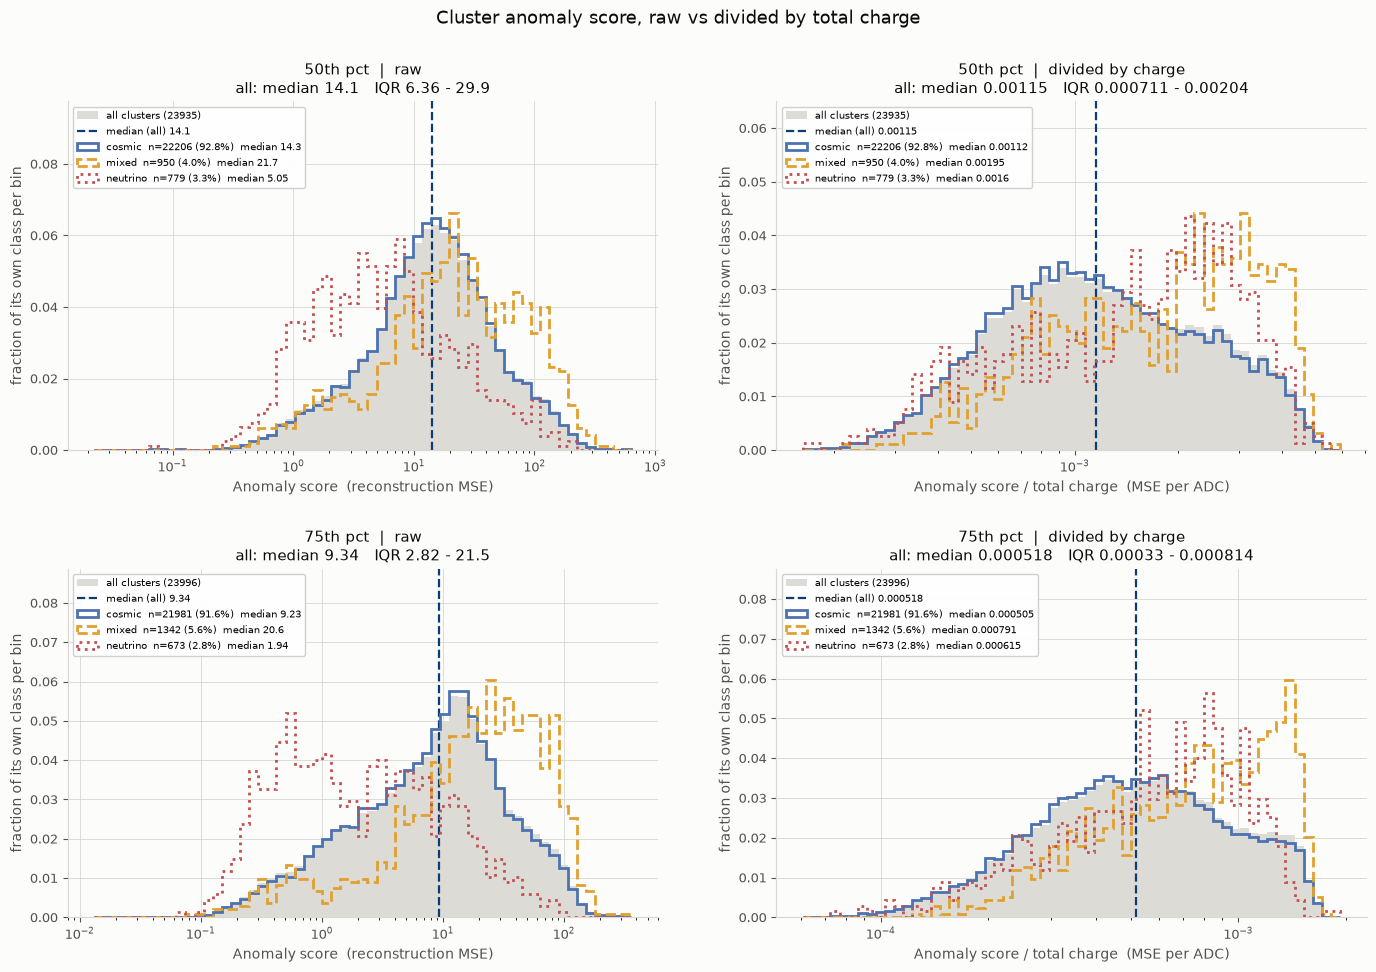


median score by truth class  (ratio = class median / cosmic median)
pct   score                    cosmic        mixed     neutrino
----------------------------------------------------------------
50    raw                       14.25        21.74        5.052
        vs cosmic               1.00x         1.53x        0.35x
50    raw / charge           0.001123     0.001951     0.001603
        vs cosmic               1.00x         1.74x        1.43x
75    raw                       9.235        20.59        1.937
        vs cosmic               1.00x         2.23x        0.21x
75    raw / charge          0.0005049     0.000791    0.0006151
        vs cosmic               1.00x         1.57x        1.22x

pct   | rho(raw, charge)         | rho(raw/charge, charge) 
----------------------------------------------------------
50    | 0.831                    | 0.111                   
75    | 0.928                    | 0.358                   


In [133]:
from matplotlib.ticker import NullFormatter

NBINS = 60
MED_C = "#0b3d73"
ALL_C = "#dcdbd6"                                        # the "all clusters" backdrop
CLS_NAMES = ("cosmic", "mixed", "neutrino")
CLS_COL = ("#4C72B0", "#E0A030", "#C44E52")
CLS_LS = ("-", "--", ":")

if DATASET != "crop":
    print("!! DATASET=%r but the truth CSVs are built for the CROP files -- SCORES idx would "
          "mismap.  Truth split below assumes crop." % DATASET)


def truth_class_of(pct):
    """Truth class per SCORED cluster, aligned to the SCORES[pct] arrays.

    SCORES[pct]['idx'] are rows of clusters_padded_<pct>, and the padded truth CSV has one row
    per padded row in the same order, so it indexes straight through.  Clusters whose frame
    holds no reconstructed hits have percent_nu = NaN and are returned as -1 (unclassifiable).
    """
    f = TRUTH[pct]["percent_nu"].to_numpy()[SCORES[pct]["idx"]]
    c = np.full(f.size, 1, np.int8)                      # 1 = mixed
    c[f <= 0.0] = 0                                      # 0 = pure cosmic
    c[f >= 100.0] = 2                                    # 2 = pure neutrino
    c[~np.isfinite(f)] = -1
    return c


CLS = {p: truth_class_of(p) for p in PCTS}
for p in PCTS:
    n_bad = int((CLS[p] < 0).sum())
    print("%dth pct: %s%s"
          % (p, "  ".join("%s %d (%.1f%%)"
                          % (n, int((CLS[p] == i).sum()),
                             100.0 * float((CLS[p] == i).mean()))
                          for i, n in enumerate(CLS_NAMES)),
             "   [%d with no hits -> dropped]" % n_bad if n_bad else ""))


def plot_by_truth(cols, suptitle, decorate=None):
    """Score histograms split by truth class, one panel per (percentile, column).

    cols = [(SCORES key, x label, short title word), ...].  `decorate(ax, pct, key, v, c)` is
    called on each finished main axes so a caller can add its own thresholds.
    """
    nr, nc = len(PCTS), len(cols)
    fig = plt.figure(figsize=(7.1 * nc, 5.1 * nr))
    fig.patch.set_facecolor("#fcfcfb")
    outer = fig.add_gridspec(nr, nc, hspace=0.34, wspace=0.20,
                             left=0.07, right=0.985, top=0.875, bottom=0.075)

    for r, pct in enumerate(PCTS):
        z, cls = SCORES[pct], CLS[pct]
        for c, (key, xlabel, word) in enumerate(cols):
            ax = fig.add_subplot(outer[r, c])

            v = z[key]
            g = np.isfinite(v) & (v > 0) & (cls >= 0)    # log axis: drop zeros; drop no-truth
            vv, cc = v[g], cls[g]
            bins = np.logspace(np.log10(vv.min()), np.log10(vv.max()), NBINS)

            ax.hist(vv, bins=bins, color=ALL_C, weights=np.full(vv.size, 1.0 / vv.size),
                    label="all clusters (%d)" % vv.size)
            med = np.median(vv)
            ax.axvline(med, color=MED_C, ls="--", lw=1.6, label="median (all) %.3g" % med)

            for cid, name in enumerate(CLS_NAMES):
                m = cc == cid
                n = int(m.sum())
                if n == 0:
                    continue
                ax.hist(vv[m], bins=bins, histtype="step", lw=2.0, ls=CLS_LS[cid],
                        color=CLS_COL[cid], weights=np.full(n, 1.0 / n),
                        label="%s  n=%d (%.1f%%)  median %.3g"
                              % (name, n, 100.0 * n / vv.size, np.median(vv[m])))
            if decorate is not None:
                decorate(ax, pct, key, vv, cc)

            ax.set_xscale("log")
            ax.xaxis.set_minor_formatter(NullFormatter())
            _style_ax(ax)
            ax.set_ylim(0, ax.get_ylim()[1] * 1.4)       # headroom so the legend clears the curves
            ax.set_xlabel(xlabel, color=INK2)
            ax.set_ylabel("fraction of its own class per bin", color=INK2)
            ax.legend(fontsize=7.5, loc="upper left", framealpha=0.92)
            ax.set_title("%dth pct  |  %s\nall: median %.3g   IQR %.3g - %.3g"
                         % (pct, word, med, *np.percentile(vv, [25, 75])),
                         color=INK, fontsize=11)

    fig.suptitle(suptitle, fontsize=13, color=INK, y=0.965)
    plt.show()


plot_by_truth([("raw", "Anomaly score  (reconstruction MSE)", "raw"),
               ("scaled", "Anomaly score / total charge  (MSE per ADC)", "divided by charge")],
              "Cluster anomaly score, raw vs divided by total charge")

# Does either score actually separate the classes?  Median ratio vs cosmic says it plainly.
print("\nmedian score by truth class  (ratio = class median / cosmic median)")
print("%-5s %-18s %12s %12s %12s" % ("pct", "score", "cosmic", "mixed", "neutrino"))
print("-" * 64)
for pct in PCTS:
    z, cls = SCORES[pct], CLS[pct]
    for key, word in (("raw", "raw"), ("scaled", "raw / charge")):
        v = z[key]
        g = np.isfinite(v) & (v > 0) & (cls >= 0)
        meds = [np.median(v[g & (cls == i)]) if (g & (cls == i)).any() else np.nan
                for i in range(3)]
        print("%-5d %-18s %12.4g %12.4g %12.4g" % (pct, word, *meds))
        print("%-5s %-18s %12s %12.2fx %11.2fx"
              % ("", "  vs cosmic", "1.00x", meds[1] / meds[0], meds[2] / meds[0]))

# The same comparison as one number, and it needs no truth labels: how strongly does each score
# still track charge?  A large drop from left to right means the division actually removed the
# charge scale rather than just relabelling the axis.
print("\n%-5s | %-24s | %-24s" % ("pct", "rho(raw, charge)", "rho(raw/charge, charge)"))
print("-" * 58)
for pct in PCTS:
    z = SCORES[pct]
    g = np.isfinite(z["scaled"]) & (z["raw"] > 0)
    print("%-5d | %-24.3f | %-24.3f"
          % (pct, spearman(z["raw"][g], z["inten"][g]), spearman(z["scaled"][g], z["inten"][g])))

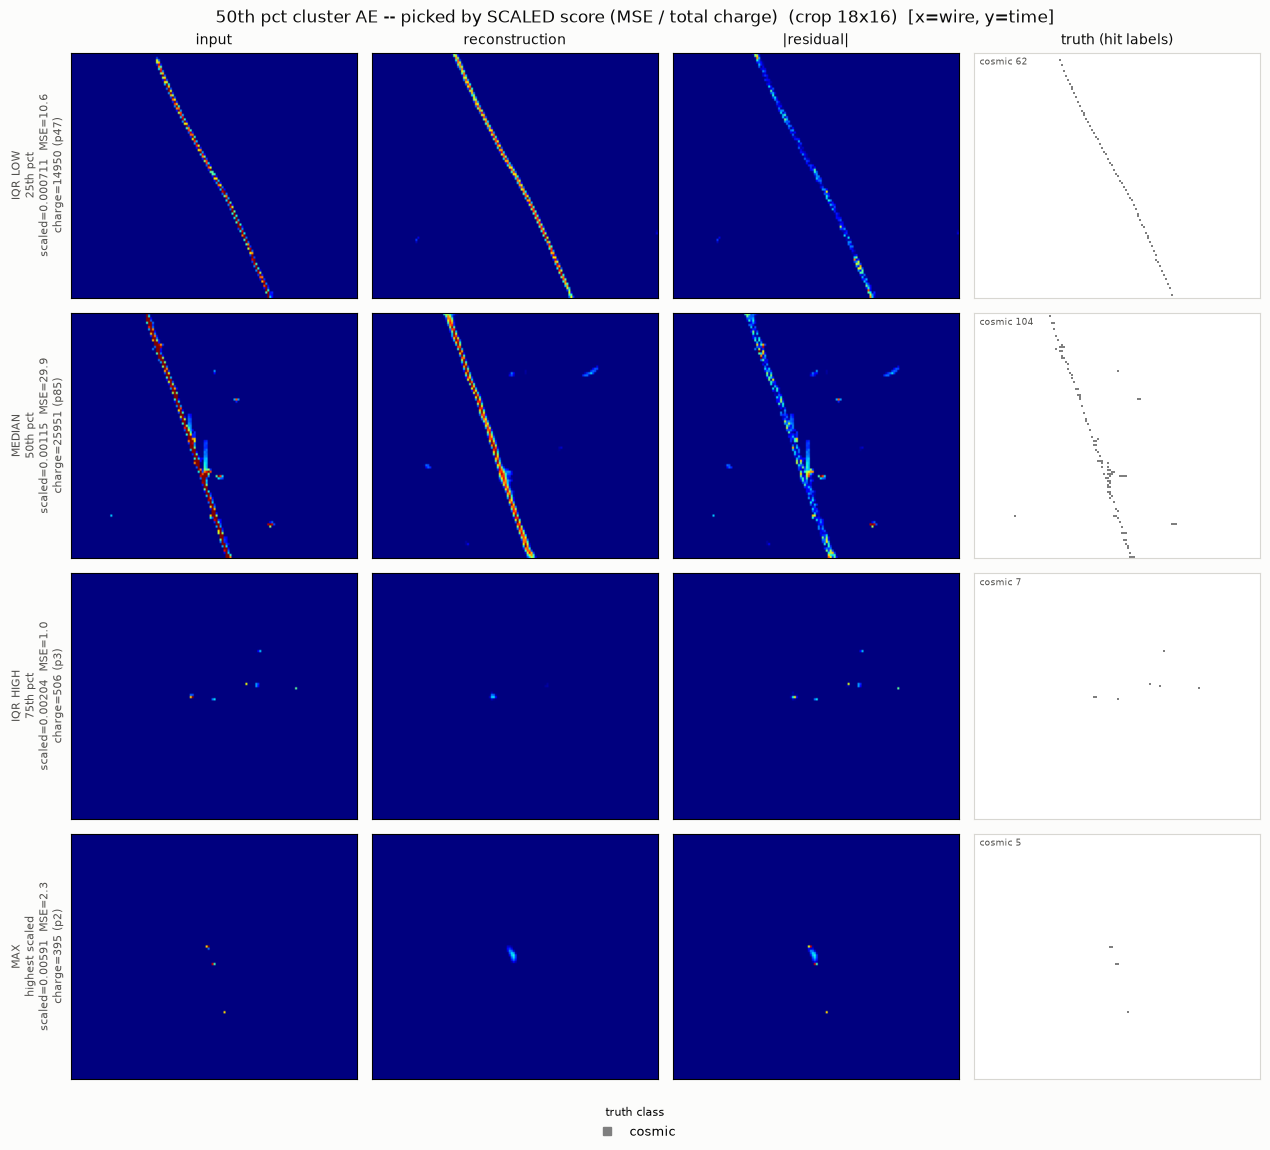

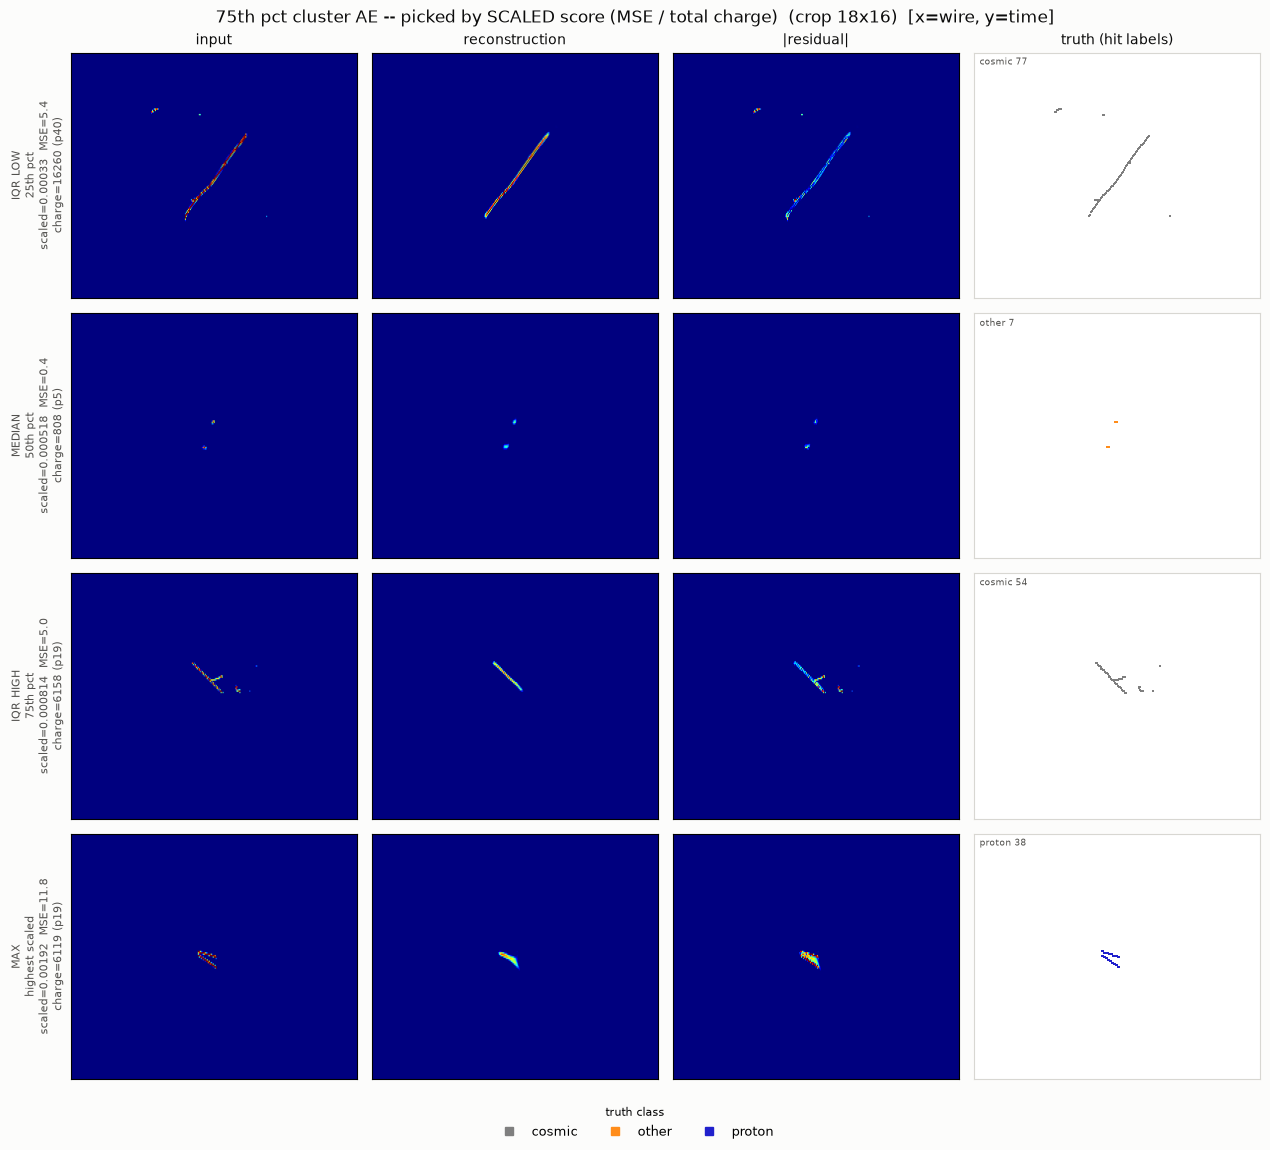

In [134]:
SCALED_PICKS = [(0.25, "IQR LOW\n25th pct"),
                (0.50, "MEDIAN\n50th pct"),
                (0.75, "IQR HIGH\n75th pct")]

for pct in PCTS:
    pos = usable_pos(pct, "scaled")
    picks = [(pick_quantile(pct, "scaled", q, pos), tag) for q, tag in SCALED_PICKS]
    picks.append((int(pos[np.argmax(SCORES[pct]["scaled"][pos])]), "MAX\nhighest scaled"))
    render_examples(
        pct, picks, "scaled", "scaled",
        "%dth pct cluster AE -- picked by SCALED score (MSE / total charge)  (%s %s)  "
        "[x=wire, y=time]" % (pct, DATASET, TILE_TAG))

### Anomaly score correlation for total charge (cropped)

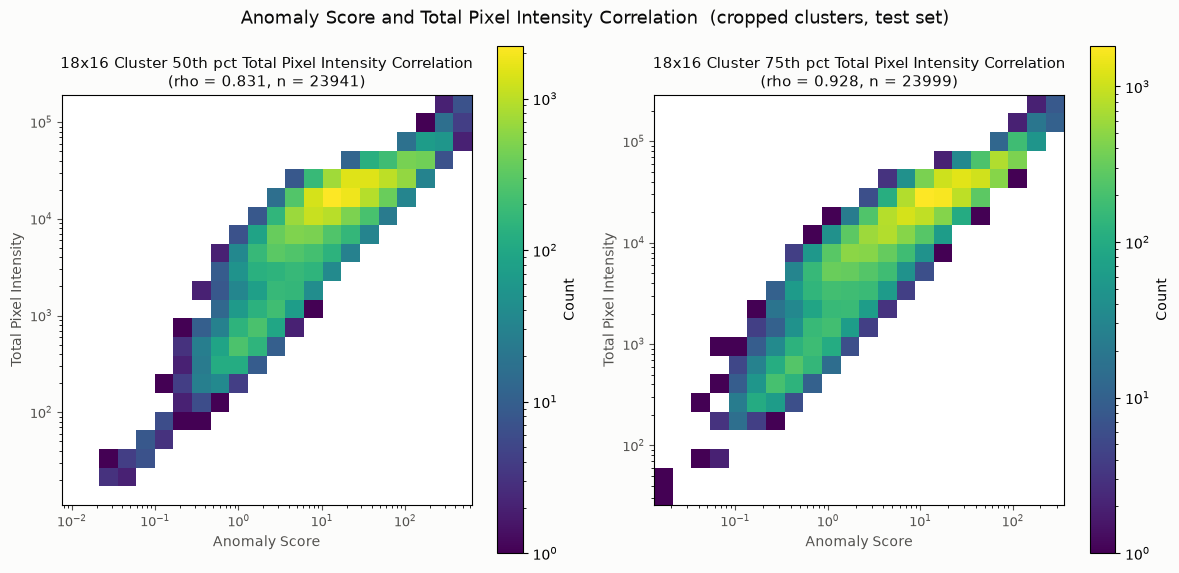

In [135]:
# FIREFLY Fig. 12 style: anomaly score (x) vs total pixel intensity (y) for the CROPPED
# clusters, one panel per percentile.  Same conventions as the paper figure -- both axes log,
# a square 2-D COUNT histogram in viridis with a log colour scale, empty bins left white.
#
# Read it as: a tight narrow diagonal means the anomaly score is very nearly a restatement of
# how much charge is in the frame (the paper reads the positive trend as "more ionization ->
# more possible reconstruction loss"); a broad cloud means charge is only one driver and
# topology still has room to matter.  The Spearman rho in each title is that tightness as a
# single number.  Needs the setup cell above (SCORES, spearman).
SCORE_FLOOR = 0.0        # FIREFLY excludes anomaly scores < 1; 0 keeps everything visible
NBINS_2D = 22            # per axis, log-spaced -- roughly the chunky bin size of the paper figure

fig, axes = plt.subplots(1, len(PCTS), figsize=(6.0 * len(PCTS), 5.8), squeeze=False)
fig.patch.set_facecolor("#fcfcfb")

for col, pct in enumerate(PCTS):
    a = axes[0][col]
    z = SCORES[pct]
    g = (z["raw"] > SCORE_FLOOR) & (z["raw"] > 0) & (z["inten"] > 0)
    x, y = z["raw"][g], z["inten"][g]                  # x = score, y = charge (paper's orientation)
    xb = np.logspace(np.log10(x.min()), np.log10(x.max()), NBINS_2D + 1)
    yb = np.logspace(np.log10(y.min()), np.log10(y.max()), NBINS_2D + 1)

    hh = a.hist2d(x, y, bins=[xb, yb], cmap="viridis", norm=LogNorm(), cmin=1)
    fig.colorbar(hh[3], ax=a, label="Count")

    a.set_xscale("log")
    a.set_yscale("log")
    a.set_box_aspect(1)
    a.set_xlabel("Anomaly Score", color=INK2)
    a.set_ylabel("Total Pixel Intensity", color=INK2)
    a.tick_params(colors=INK2, labelsize=9)
    a.set_title("%s Cluster %dth pct Total Pixel Intensity Correlation\n(rho = %.3f, n = %d)"
                % (TILE_TAG, pct, spearman(x, y), x.size), color=INK, fontsize=11)

fig.suptitle("Anomaly Score and Total Pixel Intensity Correlation  (cropped clusters, test set)",
             fontsize=13, color=INK)
fig.tight_layout()
plt.show()

### Charge-normalized anomaly scores | Charge as a non-factor

Dividing by charge answers *"is it anomalous per unit of charge?"* but leaves the score on an
unreadable `~1e-3` scale and still carries a rank correlation of 0.11 / 0.36 with charge, because
the MSE is not exactly proportional to charge (fitted log-log slope 0.95 / 1.09, and curved).

The **charge-normalized** score instead divides each cluster by the *median score of clusters at the
same charge*, so it is centred on **1.0** and reads directly:

| `norm` | meaning |
|---|---|
| 1.0 | exactly as hard to reconstruct as its equally-bright peers |
| 3.0 | three times the typical error at that brightness — genuinely anomalous |
| 0.5 | reconstructed twice as cleanly as its peers |

Rank correlation with charge falls to **~0.01**, so a faint cluster and a bright one are judged on
the same footing.

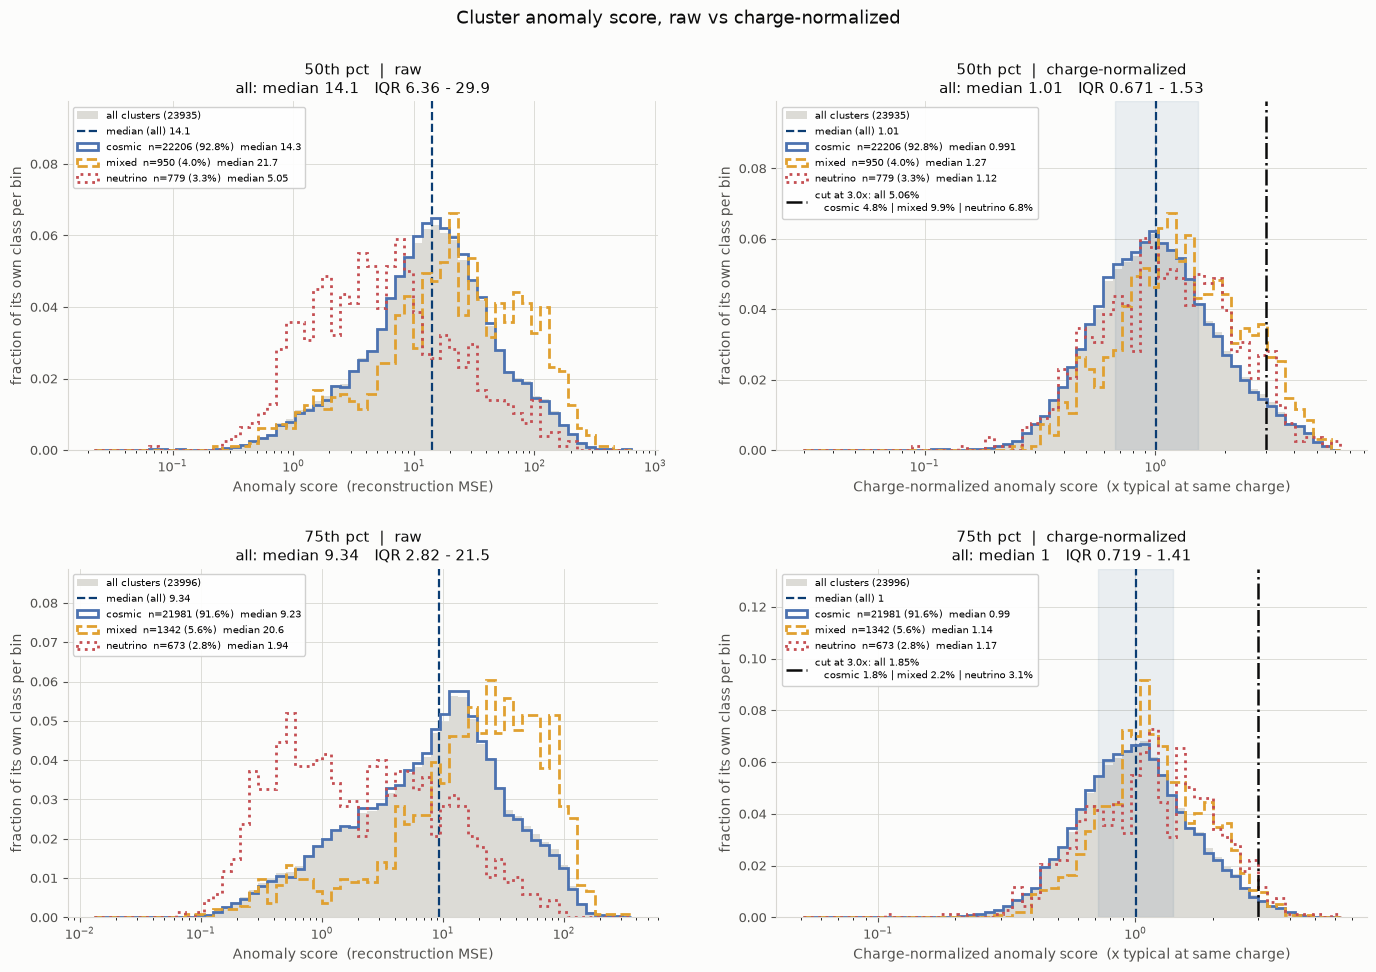


what sits above norm > 3.0x
pct   sample       cosmic    mixed neutrino          n
--------------------------------------------------------
50    all          92.78%    3.97%    3.25%      23935
50    > 3.0x       87.87%    7.76%    4.37%       1212
75    all          91.60%    5.59%    2.80%      23996
75    > 3.0x       88.76%    6.52%    4.72%        445

Spearman rank correlation with total charge  (0 = charge is a non-factor)
pct   | raw        | raw / charge   | charge-normalized
------------------------------------------------------
50    | 0.831      | 0.111          | 0.012         
75    | 0.928      | 0.358          | 0.007         


In [136]:
# The charge-NORMALIZED anomaly score, split by truth class.
#
# `norm` (setup cell) divides each cluster by the MEDIAN score of clusters at the SAME charge:
#       norm = 1   -> exactly as hard to reconstruct as its equally-bright peers
#       norm = 3   -> three times the typical error at that brightness = actually anomalous
#       norm = 0.5 -> reconstructed twice as cleanly as its peers
# Charge is a non-factor by construction (rho ~ 0.01, printed below), so a faint neutrino can
# now out-score a bright cosmic -- which is exactly the comparison the truth split makes
# readable.  Same three classes as the cell above (cosmic = 0% neutrino charge, neutrino =
# 100%, mixed = strictly between); same crude hard cut, same case for a gradient later.
#
# LEFT = raw score for reference, RIGHT = normalized; TOP = 50th pct, BOTTOM = 75th pct.
# Grey = all clusters, outlines = each class normalized to its own total.  The dash-dot line is
# ANOM_CUT; the legend gives the fraction of EACH class above it, which is the number that says
# whether the cut is worth anything -- and the table below turns that into the purity of the
# selected sample.  Reuses plot_by_truth / CLS / CLS_* from the scaled-score cell above.
ANOM_CUT = 3.0           # norm above this = "anomalous once charge is taken out of it"


def _cut_marks(ax, pct, key, vv, cc):
    """On the normalized column only: the ordinary IQR band and the ANOM_CUT threshold."""
    if key != "norm":
        return
    q1, q3 = np.percentile(vv, [25, 75])
    ax.axvspan(q1, q3, color=MED_C, alpha=0.07)
    above = " | ".join("%s %.1f%%" % (CLS_NAMES[i], 100.0 * float((vv[cc == i] > ANOM_CUT).mean()))
                       for i in range(len(CLS_NAMES)) if (cc == i).any())
    # NOT red / dotted -- that is the neutrino class's own encoding in these panels
    ax.axvline(ANOM_CUT, color=INK, ls="-.", lw=1.8,
               label="cut at %.1fx: all %.2f%%\n   %s"
                     % (ANOM_CUT, 100.0 * float((vv > ANOM_CUT).mean()), above))


plot_by_truth([("raw", "Anomaly score  (reconstruction MSE)", "raw"),
               ("norm", "Charge-normalized anomaly score  (x typical at same charge)",
                "charge-normalized")],
              "Cluster anomaly score, raw vs charge-normalized",
              decorate=_cut_marks)

# What the cut actually buys: purity of the selected sample vs the sample as a whole.
print("\nwhat sits above norm > %.1fx" % ANOM_CUT)
print("%-5s %-10s %8s %8s %8s %10s" % ("pct", "sample", "cosmic", "mixed", "neutrino", "n"))
print("-" * 56)
for pct in PCTS:
    z, cls = SCORES[pct], CLS[pct]
    v = z["norm"]
    g = np.isfinite(v) & (v > 0) & (cls >= 0)
    for label, sel in (("all", g), ("> %.1fx" % ANOM_CUT, g & (v > ANOM_CUT))):
        n = int(sel.sum())
        fr = [100.0 * float((cls[sel] == i).mean()) if n else np.nan for i in range(3)]
        print("%-5d %-10s %7.2f%% %7.2f%% %7.2f%% %10d" % (pct, label, *fr, n))

# Proof that the normalization did what it claims: charge should be gone from the ranking.
print("\nSpearman rank correlation with total charge  (0 = charge is a non-factor)")
print("%-5s | %-10s | %-14s | %-14s" % ("pct", "raw", "raw / charge", "charge-normalized"))
print("-" * 54)
for pct in PCTS:
    z = SCORES[pct]
    g = np.isfinite(z["norm"]) & (z["raw"] > 0)
    print("%-5d | %-10.3f | %-14.3f | %-14.3f"
          % (pct, spearman(z["raw"][g], z["inten"][g]), spearman(z["scaled"][g], z["inten"][g]),
             spearman(z["norm"][g], z["inten"][g])))

### Input v.s. Reconstruction | What the charge-normalized score selects

Three rows per percentile, shown as **input | reconstruction | |residual| | truth**, all picked on
the charge-normalized score (`norm`):

- **TYPICAL** (`norm ~ 1`) — the median cluster, i.e. what "ordinary" reconstruction looks like
- **ANOMALOUS** (`norm ~ p99.9`) — high error *for its brightness*, the thing we actually want to find
- **MOST ANOMALOUS** (`max norm`) — the single most anomalous cluster once charge is divided out

Each row label carries `norm`, the raw MSE, and the cluster's **charge percentile**, so the
anomalous picks can be checked against the suspicion that they are just bright ones.

The **truth** column follows the `semantic_label` plot convention: every plane-2 hit inside the
cluster's frame, on white, coloured by the Geant4 particle that deposited most of its energy.
A hit with no Geant4 parent at all comes from the beam-off cosmic overlay and is labelled `cosmic`.

| class | meaning |
|---|---|
| `cosmic` | no Geant4 parent — from the real beam-off cosmic overlay |
| `muon` / `pion` / `proton` | dominant depositor has \|PDG\| = 13 / 211 / 2212 |
| `other` | any other simulated particle (electrons, photons, neutrons, …) |

Note this is a **hit** scatter, not an ADC image, so it is sparser than the input panel — the input
is wire ADC, while truth exists only where a reconstructed hit does. Requires the raw
`bnb_WithWire_<NN>.h5` files; if they are not found the panel says so rather than failing.

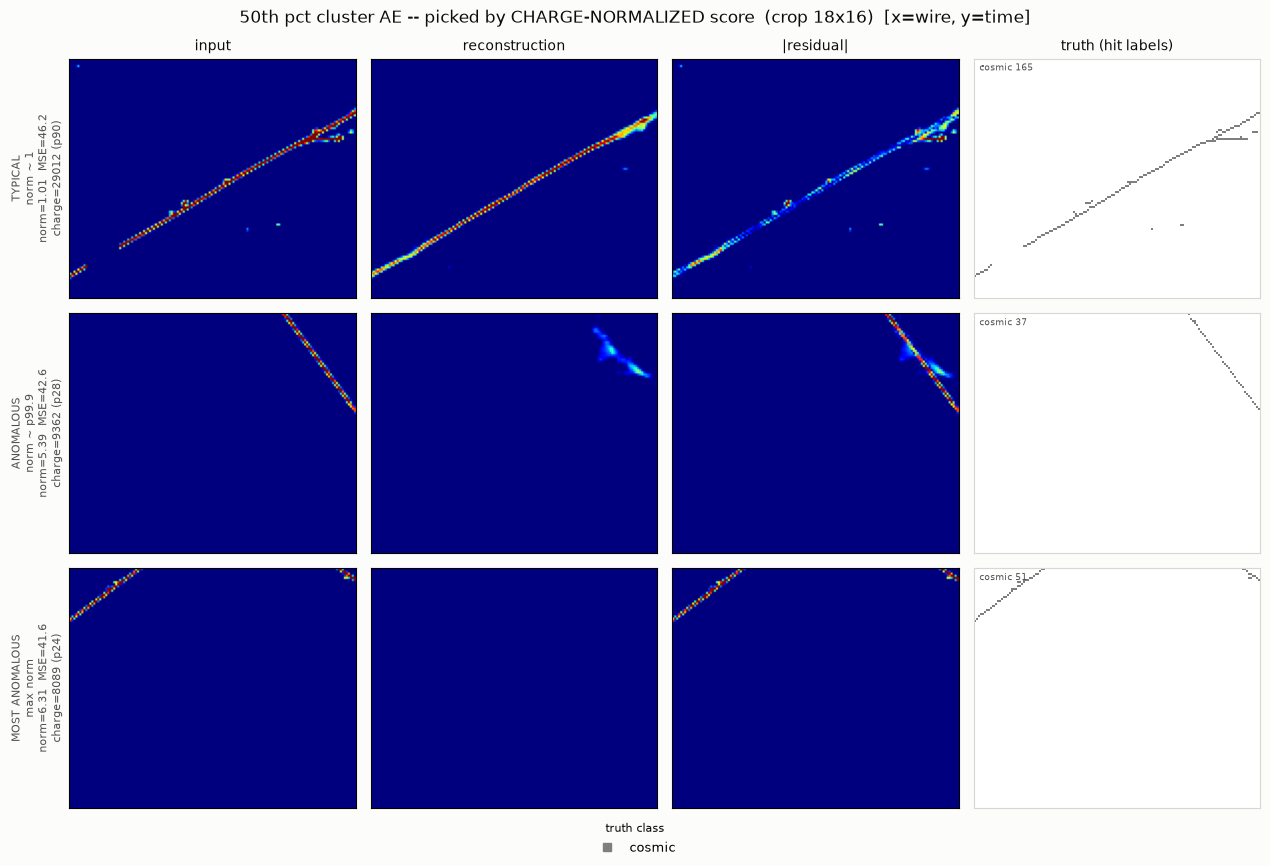

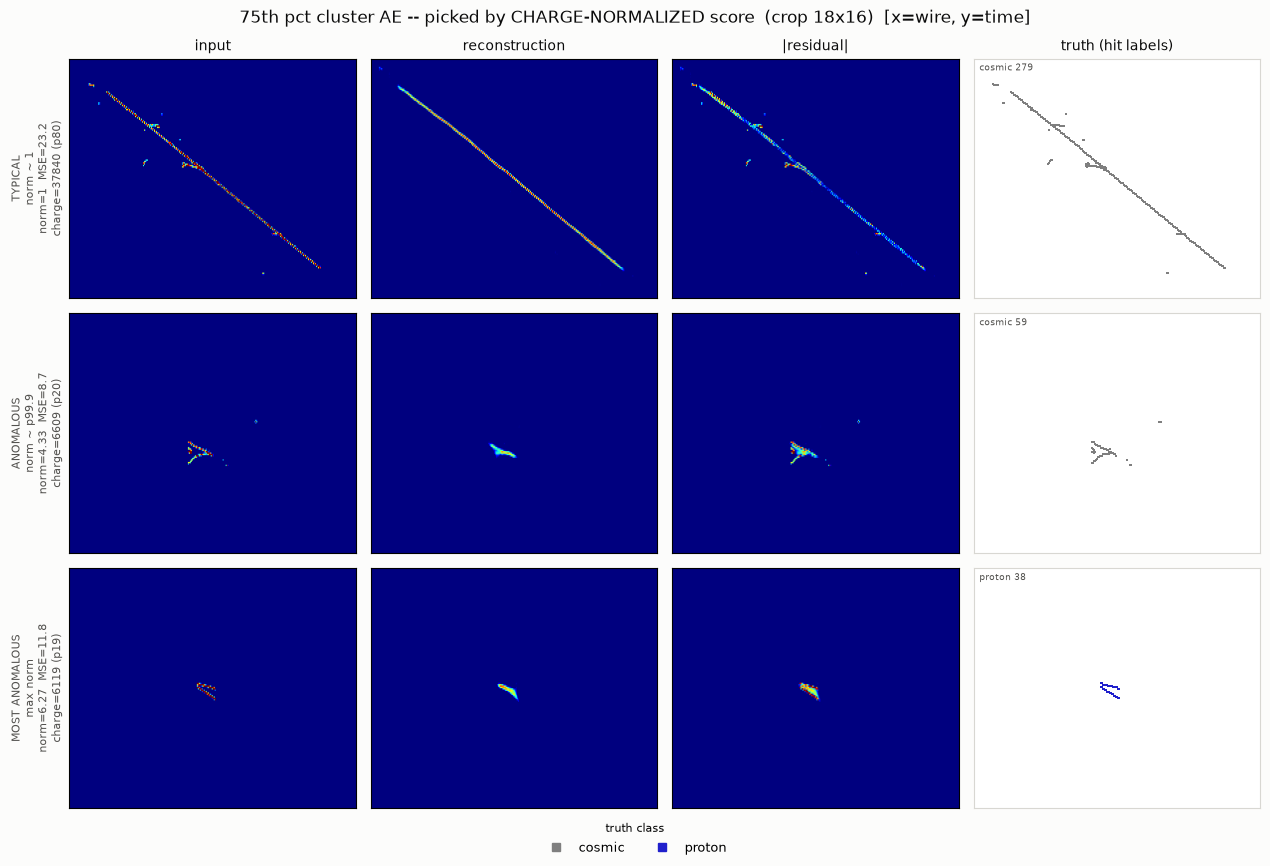

In [137]:
# What the charge-NORMALIZED score selects, same four panels: input | reconstruction | |residual|
# | truth.  Three rows per percentile, all picked on `norm` (charge is a non-factor):
#
#   TYPICAL   norm ~ 1        the median cluster -- what "ordinary" reconstruction looks like
#   ANOMALOUS norm ~ p99.9    high error FOR ITS BRIGHTNESS -- the thing we actually want to find
#   ANOMALOUS norm = max      the single most anomalous cluster once charge is divided out
#
# Row labels carry norm, the raw MSE, and the cluster's charge PERCENTILE, so you can check the
# anomalous picks are not simply the bright ones -- compare against the SCALED picks above, which
# still drift with brightness.  Needs the setup + machinery cells above.
for pct in PCTS:
    pos = usable_pos(pct, "norm")
    picks = [(pick_quantile(pct, "norm", 0.50, pos), "TYPICAL\nnorm ~ 1"),
             (pick_quantile(pct, "norm", 0.999, pos), "ANOMALOUS\nnorm ~ p99.9"),
             (int(pos[np.argmax(SCORES[pct]["norm"][pos])]), "MOST ANOMALOUS\nmax norm")]
    render_examples(
        pct, picks, "norm", "norm",
        "%dth pct cluster AE -- picked by CHARGE-NORMALIZED score  (%s %s)  [x=wire, y=time]"
        % (pct, DATASET, TILE_TAG))

# Binary cluster training

Overall the anomaly scores seems to be heavily biased off of charge so instead we can change our methodology such that the cluster pixels are all in a binary state. Since the pixel intensity range is from 0 - 100, we'll set any non-zero pixel to a value of 100 to ensure maximal distinguishing between the detector background and the particle signal. Also an important preface that my studies for these clusters will exclusively use the 75th percentile padding/cropping sizes 


To do this run the following command: 


`conda run --no-capture-output -n ubopendata python main_project/MBOONE/binary_cluster.py`


Or run the `binary_cluster.py` script.




Which should yield


Then in the `Cluster_Training.py`, change the input to account for the new binary model. This should be an easy task as you go to the top of the script and enable binary as the mode.

### Raw | padded 75th | binary 75th | truth

The same cluster in all four frames, a new **random** one every time the cell is run: the
variable-size raw crop, the 288x176 75th-percentile frame the autoencoder is fed, that frame after
`binary_cluster.py` throws the charge magnitude away (any lit pixel -> 100), and the plane-2 truth
hits inside the cluster box.

Panels 2 and 3 share the same 0-100 colour scale, so panel 3 sitting at the top of it everywhere is
the point -- all that is left for the network to reconstruct is occupancy, not brightness. Only the
75th percentile appears because the binary set is built from the 75th alone.

cluster row 164932  (pool='any')  -- re-run the cell for another, or set BIN_ROW=164932 to pin it


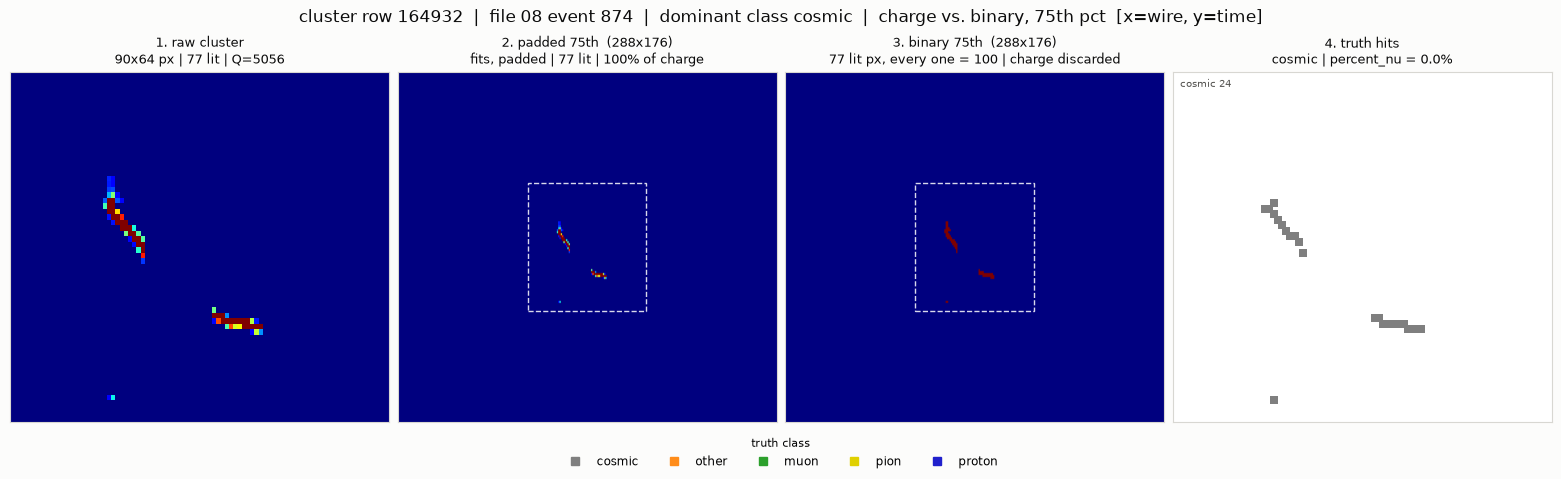

164932

In [179]:
# BINARY vs. CHARGE -- the same random cluster in four frames.  Re-run the cell for a new one.
#
#   1 raw cluster    the variable-size crop tile_cluster.py pass 1 wrote (real ADC)
#   2 padded 75th    the 288x176 frame the AE is fed        clusters_padded_75_18x16.h5
#   3 binary 75th    same frame, charge magnitude removed   clusters_padded_binary_75_18x16.h5
#                    (every lit pixel -> 100, everything else 0)
#   4 truth hits     every plane-2 hit in the cluster's box, coloured by the Geant4 particle
#                    that deposited most of its energy
#
# Only the 75th percentile appears because binary_cluster.py builds the binary set from it
# alone.  Panels 2 and 3 share one colour scale (0 -> saturation = 100), so panel 3 sitting at
# the top of the scale everywhere IS the point: the network can no longer tell a faint pixel
# from a bright one, only lit from unlit.  All four panels are the same cluster row, and the
# binary file carries the source's row order verbatim, so the index maps straight through.
# Needs the setup cells above (TRUTH, CTL, CIMG_T, RAW_DIR_T, SIZES).
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

BIN_PCT = 75              # the binary set only exists for the 75th
BIN_POOL = "any"     # "neutrino" (percent_nu > 50) | "any" -- a uniform pick is ~90% cosmic
BIN_ROW = None            # set to an int to pin one cluster; None = new random pick every run


def show_binary(row):
    """Four panels for one cluster row (same row in the raw, padded, binary and truth tables)."""
    m = TRUTH["raw"].loc[row]
    py1, py2 = int(m.bbox_wire_lo), int(m.bbox_wire_hi)      # wire = image axis 0
    px1, px2 = int(m.bbox_time_lo), int(m.bbox_time_hi)      # time = image axis 1
    fid, ev = int(m.source_file_id), int(m.source_event_index)
    tw, tt = SIZES[BIN_PCT]

    with h5py.File(str(CIMG_T / ("clusters_raw_%s.h5" % TILE_TAG)), "r") as f:
        lo, hi = int(f["image_offsets"][row]), int(f["image_offsets"][row + 1])
        raw_img = f["image_data"][lo:hi].reshape(int(f["image_width_px"][row]),
                                                 int(f["image_height_px"][row]))
        srcs = [s.decode() if isinstance(s, bytes) else s for s in f.attrs["source_files"]]
        SAT = float(f.attrs["saturation"])

    with h5py.File(str(CIMG_T / ("clusters_padded_%d_%s.h5" % (BIN_PCT, TILE_TAG))), "r") as f:
        pad_img = f["images"][row]
    with h5py.File(str(CIMG_T / ("clusters_padded_binary_%d_%s.h5" % (BIN_PCT, TILE_TAG))), "r") as f:
        bin_img = f["images"][row]
        SET = float(f.attrs["charge_set"])

    hw = ht = hc = None
    raw_h5 = RAW_DIR_T / srcs[fid].replace("_plane2_images", "")
    if raw_h5.exists():
        hw, ht, _q, hc = CTL.event_hit_truth(raw_h5, ev)

    fig, ax = plt.subplots(1, 4, figsize=(15.5, 4.7), constrained_layout=True)
    fig.patch.set_facecolor("#fcfcfb")

    def chrome(a, title, sub=""):
        a.set_title(title + ("\n" + sub if sub else ""), fontsize=9.5, color=INK)
        a.set_xticks([]); a.set_yticks([])
        for sp in a.spines.values():
            sp.set_color(GRIDC)

    # 1 -- raw crop, drawn in FULL-image coordinates so panel 4 lines up with it
    ax[0].imshow(raw_img.T, origin="lower", cmap="jet", vmin=0, vmax=SAT, aspect="auto",
                 extent=(py1, py2, px1, px2))
    chrome(ax[0], "1. raw cluster", "%dx%d px | %d lit | Q=%.0f"
           % (m.crop_w, m.crop_h, m.n_points, m.total_charge))

    # 2, 3 -- the 75th-pct frame before and after binarization, same colour scale, with the
    # real-data region (what survived pad_to_target's centre-crop) outlined in both.
    q = TRUTH[BIN_PCT].loc[row]
    _s0, h2, _s1, w2 = CTL.crop_window(py2 - py1, px2 - px1, tw, tt)
    panels = ((pad_img, "2. padded %dth  (%dx%d)" % (BIN_PCT, tw, tt),
               "%s | %d lit | %.0f%% of charge"
               % ("CROPPED" if q.was_cropped else "fits, padded", q.n_points,
                  100.0 * q.frac_charge_kept)),
              (bin_img, "3. binary %dth  (%dx%d)" % (BIN_PCT, tw, tt),
               "%d lit px, every one = %g | charge discarded"
               % (int((bin_img > 0).sum()), SET)))
    for k, (img, title, sub) in enumerate(panels):
        a = ax[1 + k]
        a.imshow(img.T, origin="lower", cmap="jet", vmin=0, vmax=SAT, aspect="auto",
                 extent=(0, tw, 0, tt))
        a.add_patch(Rectangle(((tw - h2) // 2, (tt - w2) // 2), h2, w2, fill=False,
                              ec="white", lw=1.0, ls="--", alpha=0.85))
        chrome(a, title, sub)

    # 4 -- truth hits inside the cluster's box, white background, one colour per class
    a = ax[3]
    a.set_facecolor("white")
    if hw is None:
        a.text(0.5, 0.5, "no plane-2 truth hits for this event\n(or raw file missing:\n%s)"
               % raw_h5.name, ha="center", va="center", fontsize=8, color=INK2,
               transform=a.transAxes)
    else:
        inb = (hw >= py1) & (hw < py2) & (ht >= px1) & (ht < px2)
        dot = float(np.clip(2600.0 / max(py2 - py1, px2 - px1), 2.0, 26.0))
        tally = []
        for name in CLASS_ORDER:
            sel = inb & (hc == name)
            if sel.any():
                tally.append("%s %d" % (name, int(sel.sum())))
                a.scatter(hw[sel], ht[sel], s=dot, marker="s", linewidths=0,
                          color=CLASS_COL[name])
        a.text(0.02, 0.98, "\n".join(tally) or "no hits in this box", transform=a.transAxes,
               ha="left", va="top", fontsize=7.5, color=INK2)
        a.set_xlim(py1, py2)
        a.set_ylim(px1, px2)
    chrome(a, "4. truth hits", "%s | percent_nu = %.1f%%" % (m.dominant_class, m.percent_nu))

    fig.legend(handles=[Line2D([], [], marker="s", ls="", ms=6, color=CLASS_COL[n], label=n)
                        for n in CLASS_ORDER],
               loc="outside lower center", ncol=5, frameon=False, fontsize=8.5,
               title="truth class", title_fontsize=8)
    fig.suptitle("cluster row %d  |  file %02d event %d  |  dominant class %s  |  "
                 "charge vs. binary, %dth pct  [x=wire, y=time]"
                 % (row, fid, ev, m.dominant_class, BIN_PCT), fontsize=12, color=INK)
    plt.show()
    return row


_r = TRUTH["raw"]
_pool = (np.nonzero((_r.percent_nu > 50).to_numpy())[0] if BIN_POOL == "neutrino"
         else np.arange(len(_r)))
# default_rng() with no seed reseeds from the OS every call -> a different cluster each run
BIN_SHOWN = BIN_ROW if BIN_ROW is not None else int(np.random.default_rng().choice(_pool))
print("cluster row %d  (pool=%r)  -- re-run the cell for another, or set BIN_ROW=%d to pin it"
      % (BIN_SHOWN, BIN_POOL, BIN_SHOWN))
show_binary(BIN_SHOWN)